**14/08/2026** -- Figure 4: Multidimensional deprivation index

Note that this is using 2000-2022 imputed data.

In [1]:
Sys.setenv(PROJ_DATA = "/home/users/cho00/miniconda3/envs/ppca/share/proj")

In [2]:
library(dplyr)
library(readr)
library(sf)
library(ggplot2)
library(cowplot)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Linking to GEOS 3.13.0, GDAL 3.10.2, PROJ 9.5.1; sf_use_s2() is TRUE



In [3]:
root <- rprojroot::find_root(rprojroot::has_file(".gitignore"))
source(file.path(root, "src/deprivation_pm_bhm/pca.R"))
source(file.path(root, "src/deprivation_pm_bhm/data_prep.R"))
source(file.path(root, "src/deprivation_pm_bhm/plotting.R"))    # plot_map() wrapper of ggplot() + geom_sf(), and density_plot()

In [4]:
# Functions for custom themes of map and density plots
maps_theme <- function() {
    theme(
        legend.position         = "bottom",
        legend.title            = element_text(size = 14, face = "plain"),
        legend.key.height       = NULL,
        legend.key.width        = unit(2, "cm"),
        legend.title.position   = "top",
        axis.text.x             = element_text(color = "black", size = 10)
    )
}

density_theme <- function() {
    theme_minimal() +
    theme(
        axis.title.y    = element_blank(),
        axis.text.y     = element_blank(),
        axis.ticks.y    = element_blank(),
        axis.title.x    = element_blank(),
        panel.grid      = element_blank(),
        axis.line.x     = element_line(color = "black"),
        axis.ticks.x    = element_line(color = "black"),
        axis.text.x     = element_text(color = "black", size = 10),
        panel.background    = element_rect(fill = NA, color = NA),
        plot.background     = element_rect(fill = NA, color = NA)
    )
}

In [5]:
SCRATCH_DIR <- Sys.getenv("SCRATCH_DIR")
DATA_PATH   <- file.path(SCRATCH_DIR, 
                         "data/spatial/fire_pm_dep_paper_data",
                         "proc_data/df_af_annual_2000_2023.csv")
NAT_BOUNDS_PATH     <- file.path(SCRATCH_DIR, 
                         "data/spatial/nat_boundaries",
                         "WB_countries_Admin0_10m")
western_sahara_path <- file.path(SCRATCH_DIR, 
                         "data/spatial/nat_boundaries",
                         "western_sahara/gadm41_ESH_0.shp")

In [6]:
nat_bounds <- sf::read_sf(NAT_BOUNDS_PATH) |> 
    filter(CONTINENT == "Africa")

In [7]:
esh_bounds <- sf::read_sf(western_sahara_path)

In [8]:
# Load data and estimate PC1 deprivation index
df <- read_csv(DATA_PATH) |> 
    filter(year <= 2022) |> 
    group_by(lon, lat) |>
    mutate(grid_id = cur_group_id()) |> # create grid_id for projecting SE vars
    ungroup()

df <- project_indicators(
    df, 
    list(edu_mean_years     = 2017,
         imp_san_access_pct = 2017,
         stunting_pct_u5    = 2017
    )
)

# Do PCA
pca_res <- compute_pca(
    df,
    method          = "ppca",
    se_indicators   = c("edu_mean_years", "imp_san_access_pct", "log_GDP_pc",
                        "child_dep_pct", "stunting_pct_u5"),
    n_pcs           = 5,
    scale           = TRUE,
    centre          = TRUE,
    seed            = 42,
    positive_vars   = c("child_dep_pct", "stunting_pct_u5"),
    negative_vars   = c("edu_mean_years", "imp_san_access_pct", "log_GDP_pc")
)

# Join PCs back onto df (helper funct)
df  <- prepare_analysis_data(df, 
                             pca_res$data, 
                             outcome = "fire_PM25_hu", # arbitrary, won't be used
                             scale_y = FALSE,
                             scale_PC1 = TRUE)

Rows: 994412 Columns: 74
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (11): geometry, ISO_A3, country, region, continent, INCOME_GRP, ECONOMY,...
dbl (63): lon, lat, total_PM25, total_O3, fire_PM25, fire_O3, fire_PM25_hu, ...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


[1] "Projecting edu_mean_years forward from 2017"


Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.0227167 (tol = 0.002, component 1)”
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model is nearly unidentifiable: very large eigenvalue
 - Rescale variables?”


[1] "Projecting imp_san_access_pct forward from 2017"


Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.00349425 (tol = 0.002, component 1)”


[1] "Projecting stunting_pct_u5 forward from 2017"


Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model failed to converge with max|grad| = 0.0278442 (tol = 0.002, component 1)”
Warning message in checkConv(attr(opt, "derivs"), opt$par, ctrl = control$checkConv, :
“Model is nearly unidentifiable: very large eigenvalue
 - Rescale variables?”
Warning message:
“Using an external vector in selections was deprecated in tidyselect 1.1.0.
ℹ Please use `all_of()` or `any_of()` instead.
  # Was:
  data %>% select(se_indicators)

  # Now:
  data %>% select(all_of(se_indicators))

See <https://tidyselect.r-lib.org/reference/faq-external-vector.html>.”
Warning message in pcaMethods::ppca(X, nPcs = n_pcs, seed = seed):
“stopped after max iterations, but rel_ch was > threshold”


In [9]:
# Get average values over 2000-2022
df_avg <- df |> 
    filter(year <= 2022) |> 
    group_by(lon, lat) |> 
    summarise(
        geometry    = first(geometry),
        PC1         = mean(PC1, na.rm = TRUE),
        .groups     = "drop"
    )

In [10]:
# Convert to sf
sf <- df_avg |> 
    mutate(geometry = sf::st_as_sfc(geometry)) |> 
    sf::st_as_sf(crs = 4326)

In [11]:
# There is an outlier of an Egypt pixel which has implausibly high child_dep_pct
sf <- sf |> filter(! (lon == 30.25 & lat == 29))

# Standardise PC1 for plotting so that units are SDs (relative to distribution of 2000-2022 means)
sf <- sf |> mutate(PC1 = as.numeric(scale(PC1)))

In [12]:
# Make map
PC1_map <- plot_map(
    data = sf, 
    color = "PC1", 
    fill = "PC1", 
    name = "Increasing deprivation (SDs) ⟶", 
    palette = "YlGnBu", 
    ticks_color = "black",
    nat_bounds_sf = nat_bounds, 
    direction = -1,
    grid_off = FALSE
) +
    geom_sf(data = esh_bounds, color = "black", fill = "gray40") + # Western Sahara #nolint
    maps_theme()

In [13]:
# Make density plot
dens_PC1 <- density_plot(sf |> filter(!is.na(PC1)),  # density() bugs out if there are NAs (but we want them as grey in the map)
                         variable = "PC1",
                         from = min(sf$PC1, na.rm = TRUE),
                         to = max(sf$PC1, na.rm = TRUE),
                         palette = "YlGnBu",
                         direction  = -1
                        ) +
    scale_x_continuous(expand = c(0, 0)) +
    scale_y_continuous(expand = expansion(mult = c(0, 0.05))) +
    density_theme()

In [14]:
options(repr.plot.height = 8, repr.plot.width = 8)

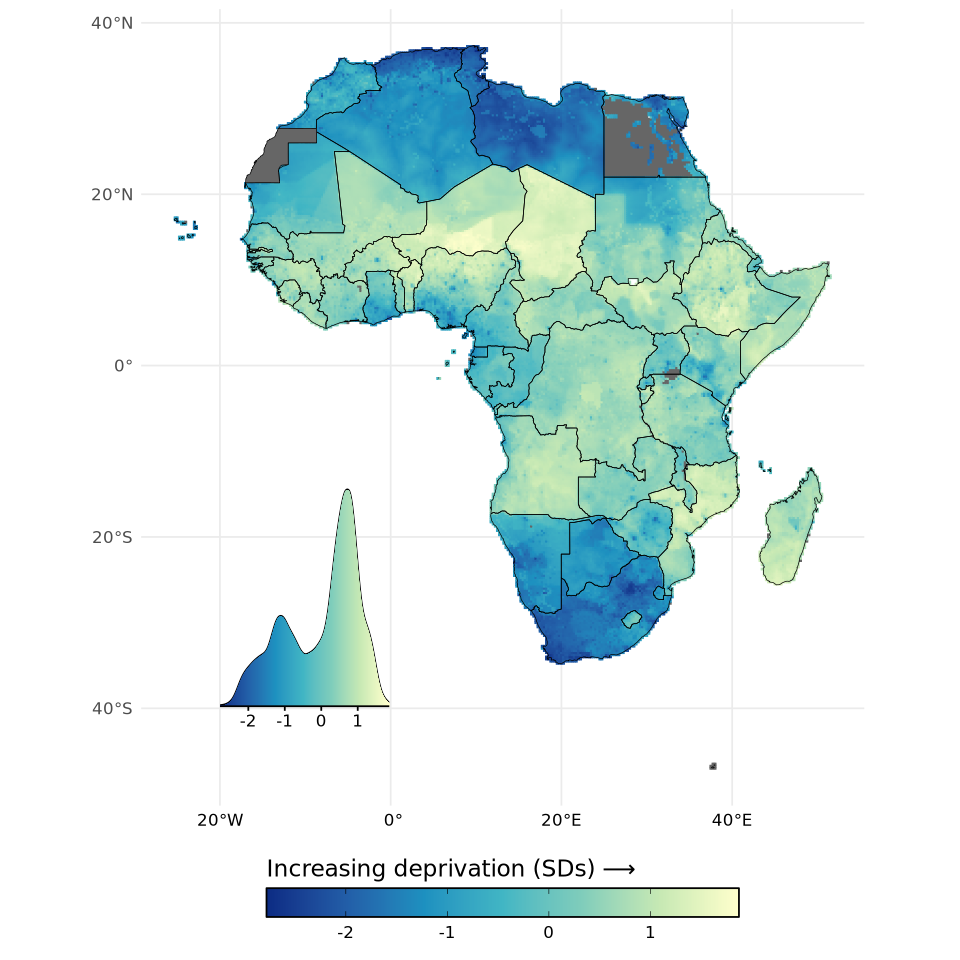

In [15]:
suppressWarnings({
    PC1_with_density <- ggdraw() +
        draw_plot(PC1_map, 0, 0, 1, 1) +
        # position the density kernels
        draw_plot(dens_PC1, 
                  x = 0.215, 
                  y = 0.23,
                  width = 0.2, 
                  height = 0.28)
})
PC1_with_density

In [16]:
ggsave(
    filename = file.path(root, "paper_results/figures/fig_4.png"),
    dpi = 450,
    width = 8,
    height = 8,
    bg = "white"
)